In [1]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF, CFT
from trees.brute_force import BruteForce
from trees.helpers import visualize_recommendations, visualize_recommendations2

N = 10000
K = 5
W = 0.5
MIN_S = 0.3
MAX_S = 0.9
SEED = 1
# OVERLAP_MEASURE = "overlap_coefficient"
OVERLAP_MEASURE = "jaccard_distance"
OVERLAP_DUPLICATE = 0.8

scores = pd.DataFrame()

data = Data()
data.generate(n=N, seed=SEED)
data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)
data.set_overlap_measure(overlap_measure=OVERLAP_MEASURE)


cf = CF(data)
algorithms = [CT(data, on="D"), CT(data, on="P"), cf, CFT(cf), BruteForce(cf) ]
for alg in algorithms:
    alg.fit()
    alg.scan()
    score = data.get_topK(alg, k=K, w=W, max_overlap_duplicate=OVERLAP_DUPLICATE)
    scores=pd.concat([scores, score], ignore_index=True)

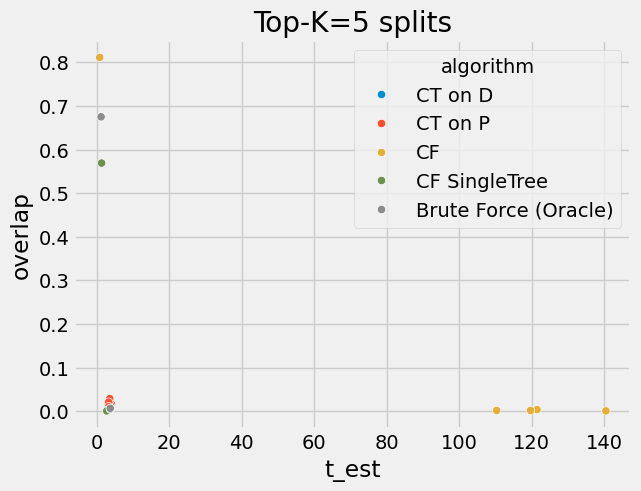

In [2]:
sns.scatterplot(data=scores, x="t_est", y="overlap", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

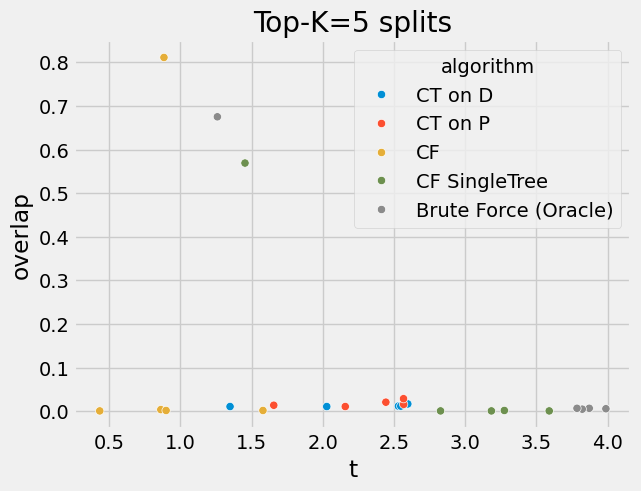

In [3]:
sns.scatterplot(data=scores, x="t", y="overlap", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

In [4]:
k_all = 10
all_scores = pd.DataFrame()
for alg in algorithms:
    score = data.get_topK(alg, k=k_all, w=W)
    all_scores=pd.concat([all_scores, score], ignore_index=True)

for alg in algorithms:
    print(alg.algorithm, ":", all_scores[all_scores["algorithm"]==alg.algorithm].shape[0], 'splits')

CT on D : 10 splits
CT on P : 10 splits
CF : 10 splits
CF SingleTree : 10 splits
Brute Force (Oracle) : 10 splits


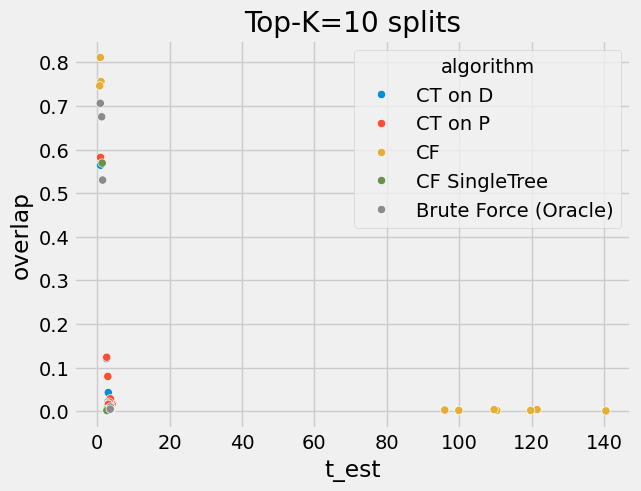

In [5]:
sns.scatterplot(data=all_scores, x="t_est", y="overlap", hue="algorithm")
plt.title(f"Top-K={k_all} splits")
plt.show()

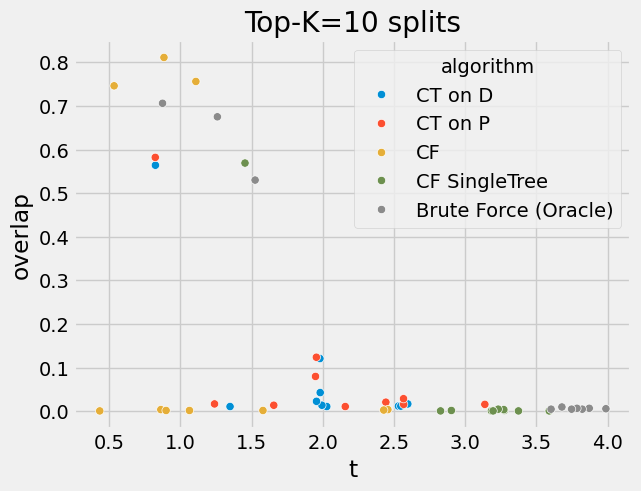

In [6]:
sns.scatterplot(data=all_scores, x="t", y="overlap", hue="algorithm")
plt.title(f"Top-K={k_all} splits")
plt.show()

Text(0.5, 1.0, "User's P: feature_4 > -1.1303065608511416")

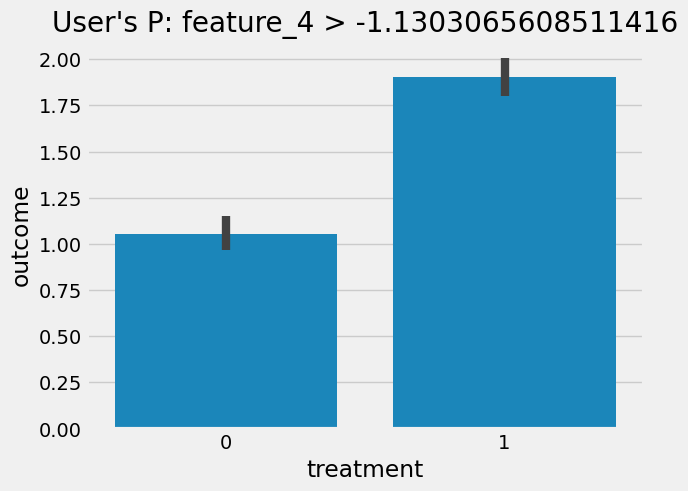

In [7]:
# visualize the user's query data.q_df where T0=1 and T1=0

# create a barplot grouping T for data.q_df
sns.barplot(x='treatment', y='outcome', data=data.q_df)
plt.title("User's P: "+ data.p)

In [8]:
import polars as pl
# in the polars dataframe q_df compute the average treatment effect
t1_data = data.q_df.filter(pl.col("treatment") == 1).select(pl.col("outcome")).mean().item()
t0_data = data.q_df.filter(pl.col("treatment") == 0).select(pl.col("outcome")).mean().item()
ate = t1_data - t0_data

print("---- ATE FROM THE DATA ----")
print("ATE:", round(ate,3))
# print("T1:", round(t1_data,2), "T0:", round(t0_data,2))


print("---- GROUND TRUTH ATE ----")
print("ATE:", round(data.q_df.select(pl.col("ITE").mean()).item(),3))



print("---- ATE FROM CF ----")
X_subpopulation = data.q_df.select(pl.exclude(["treatment", "outcome", "ITE", "id"]))

# Compute the CATE for the subpopulation
ate = cf.forest.effect(X_subpopulation).mean()
print("ATE:", round(ate,3)) # why should this be accurate? feature_2 is not even in the tree 


---- ATE FROM THE DATA ----
ATE: 0.849
---- GROUND TRUTH ATE ----
ATE: 0.833
---- ATE FROM CF ----
ATE: 0.824


# Recommendations from CT on D

In [9]:
top_ct_d = scores[(scores['algorithm']=='CT on D')]
top_ct_d

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,unique_between_K,true_score,algorithm,execution_time
0,feature_8 <= 0.311 AND feature_0 <= 2.014 AND ...,3.998,0.017,1.25,5.25,6,160,0.0160,0.018279,1.00,0.51,2.597,4.0,1.0,0.24,CT on D,0.06
1,feature_8 <= 0.311 AND feature_0 <= 2.014 AND ...,3.900,0.011,0.17,4.07,7,122,0.0122,0.013938,0.98,0.49,2.028,5.0,1.0,0.18,CT on D,0.06
2,feature_8 > 0.311 AND feature_2 <= 0.484 AND f...,3.510,0.012,0.73,4.24,6,113,0.0113,0.012910,0.88,0.44,2.531,6.0,1.0,0.23,CT on D,0.06
3,feature_8 > 0.311 AND feature_2 <= 0.484 AND f...,3.388,0.011,-0.91,2.48,11,102,0.0102,0.011653,0.85,0.43,1.349,8.0,1.0,0.12,CT on D,0.06
4,feature_8 > 0.311 AND feature_2 <= 0.484 AND f...,3.383,0.012,0.38,3.77,7,118,0.0118,0.013481,0.85,0.43,2.548,6.0,1.0,0.23,CT on D,0.06


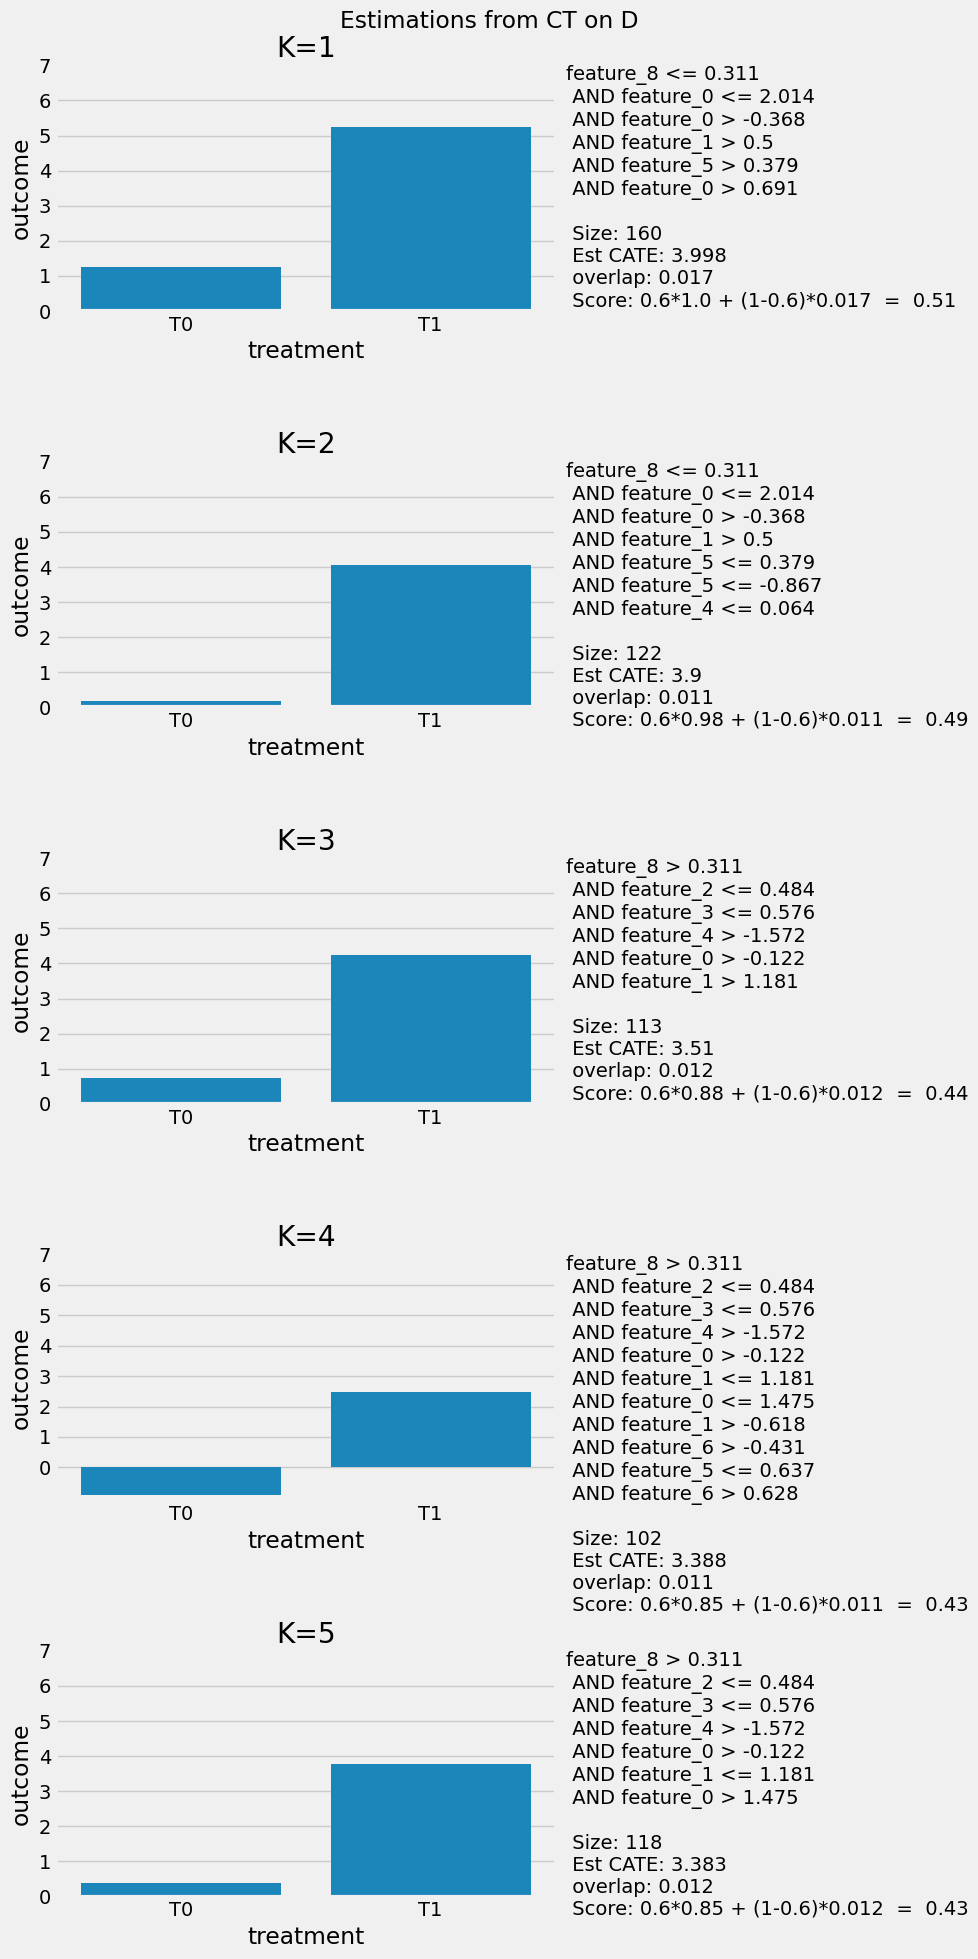

In [10]:
visualize_recommendations(data,top_ct_d)

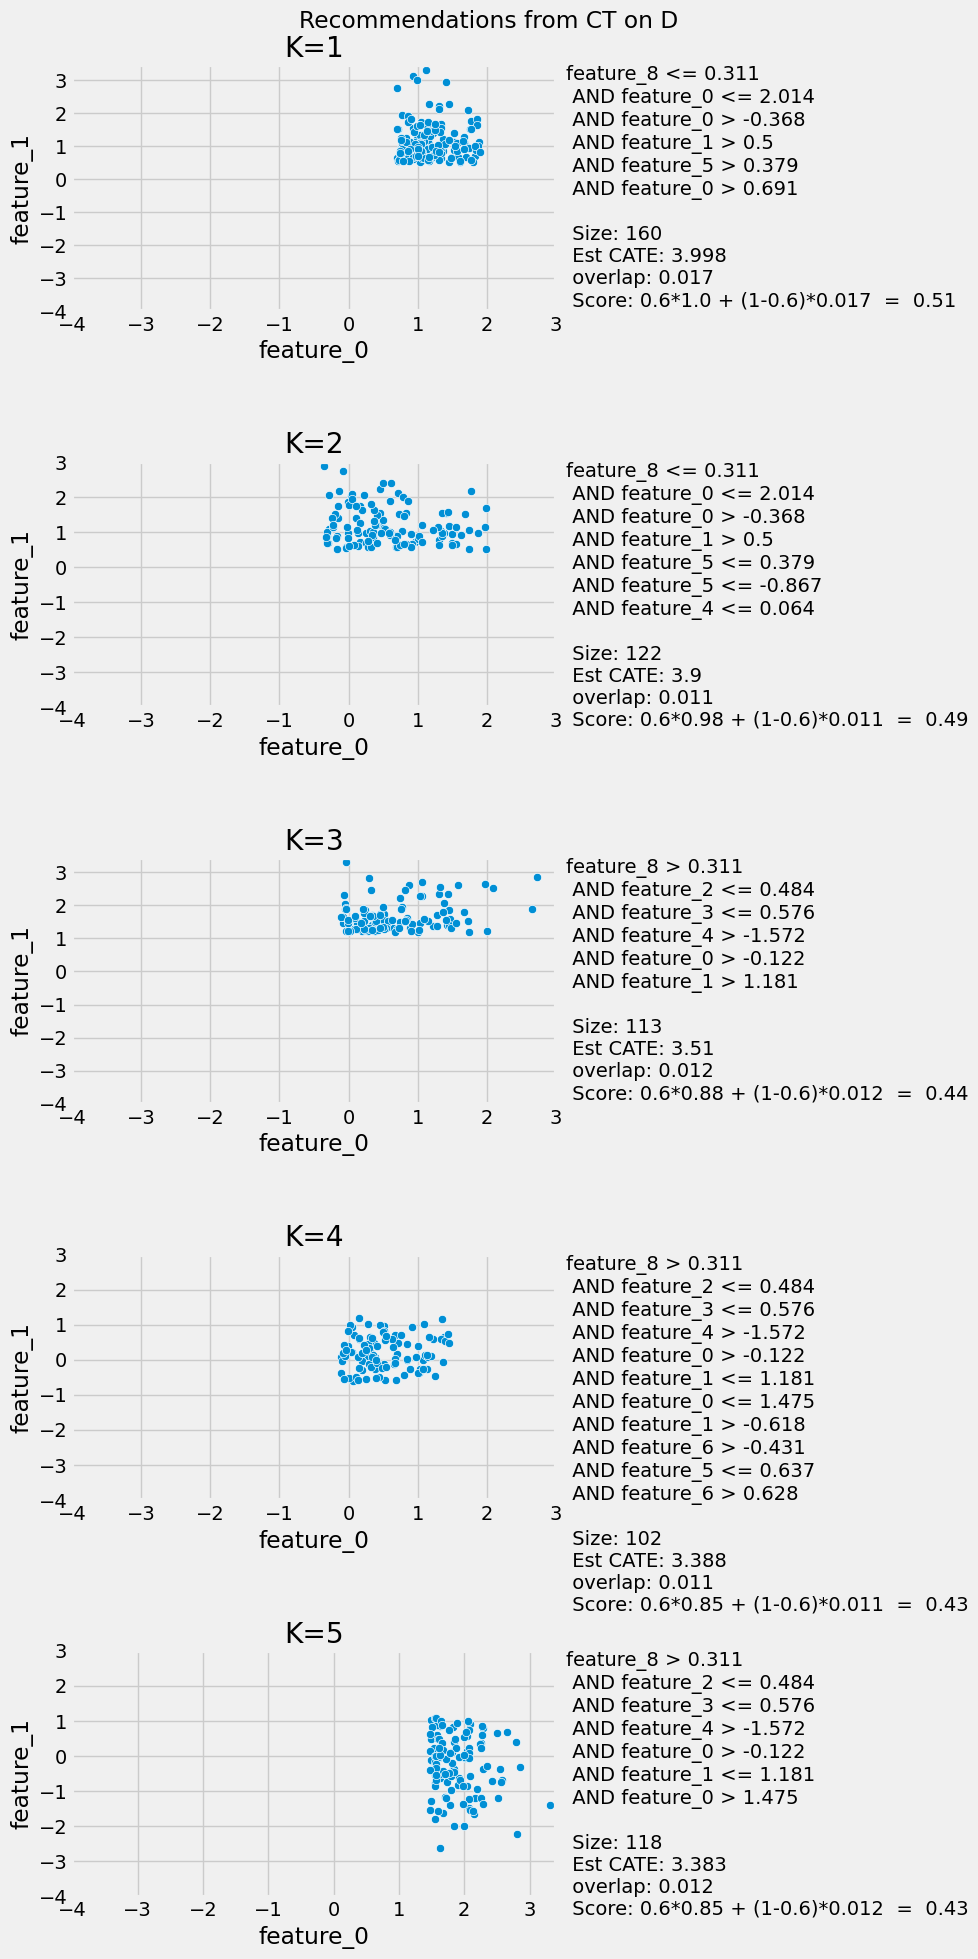

In [11]:
visualize_recommendations2(data, top_ct_d)

# Recommendations from CT on P

In [12]:
top_ct_p = scores[(scores['algorithm']=='CT on P')]
top_ct_p

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,unique_between_K,true_score,algorithm,execution_time
5,feature_8 <= 0.372 AND feature_0 <= 1.965 AND ...,4.147,0.016,0.95,5.10,7,138,0.0138,0.015766,1.00,0.51,2.568,5.0,0.85,0.23,CT on P,0.12
6,feature_8 <= 0.372 AND feature_0 <= 1.965 AND ...,3.780,0.014,-0.09,3.69,8,159,0.0159,0.018165,0.91,0.46,1.656,5.0,0.85,0.15,CT on P,0.12
7,feature_8 <= 0.372 AND feature_0 <= 1.965 AND ...,3.652,0.029,0.95,4.60,6,291,0.0291,0.033246,0.88,0.45,2.567,4.0,0.85,0.24,CT on P,0.12
8,feature_8 > 0.372 AND feature_2 <= 0.484 AND f...,3.354,0.021,0.53,3.88,7,219,0.0219,0.025020,0.81,0.41,2.443,6.0,0.85,0.22,CT on P,0.12
9,feature_8 <= 0.372 AND feature_0 <= 1.965 AND ...,3.350,0.011,0.88,4.23,7,113,0.0113,0.012910,0.81,0.41,2.158,5.0,0.85,0.19,CT on P,0.12


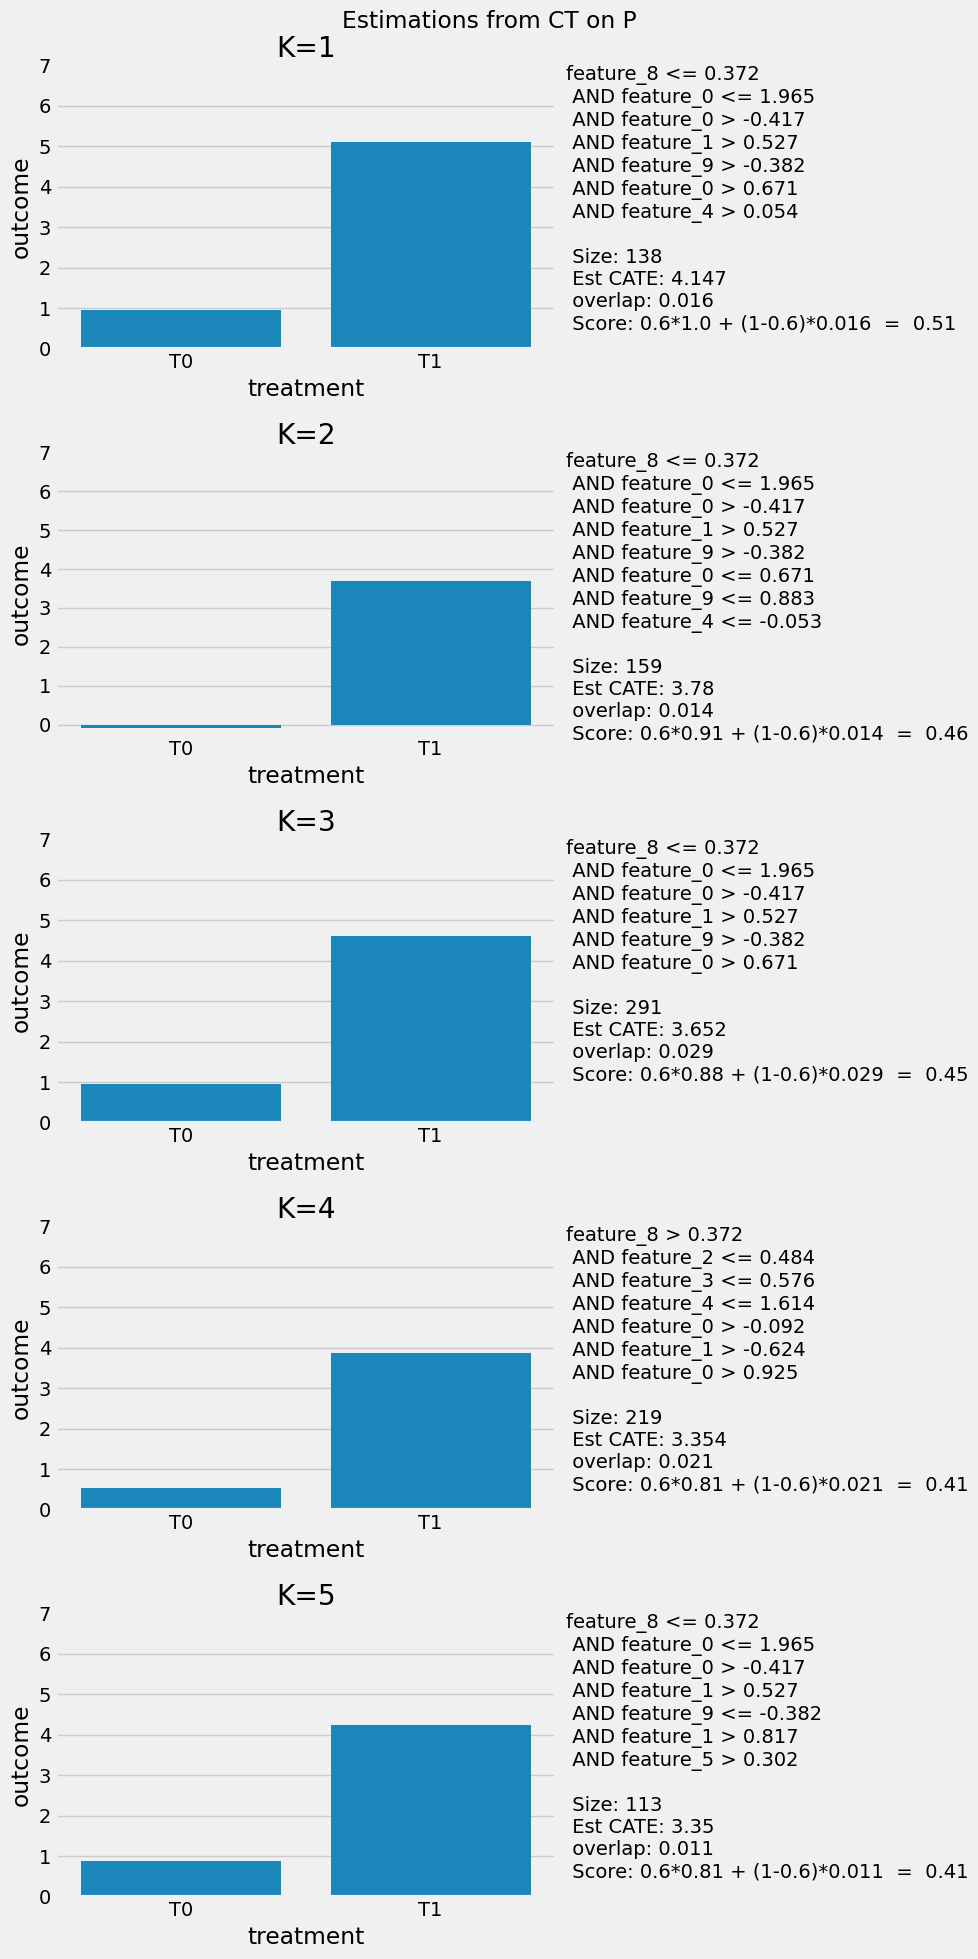

In [13]:
visualize_recommendations(data,top_ct_p)

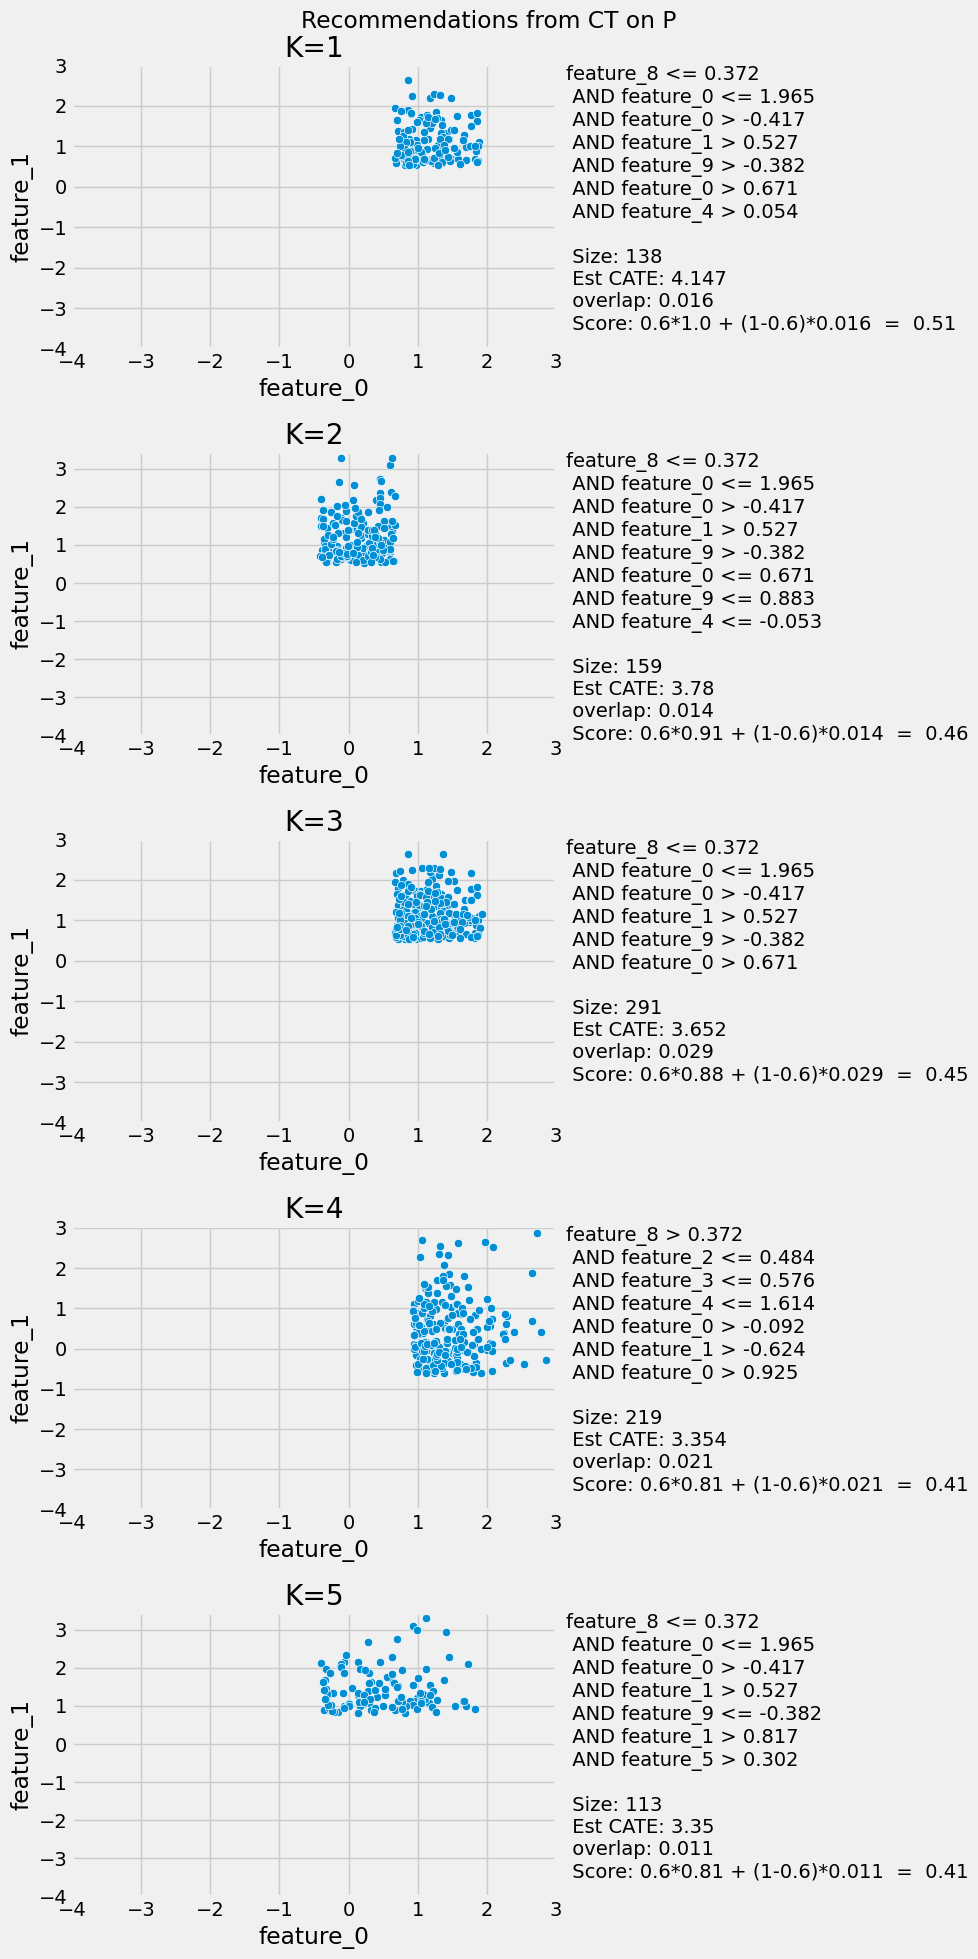

In [14]:
visualize_recommendations2(data,top_ct_p)

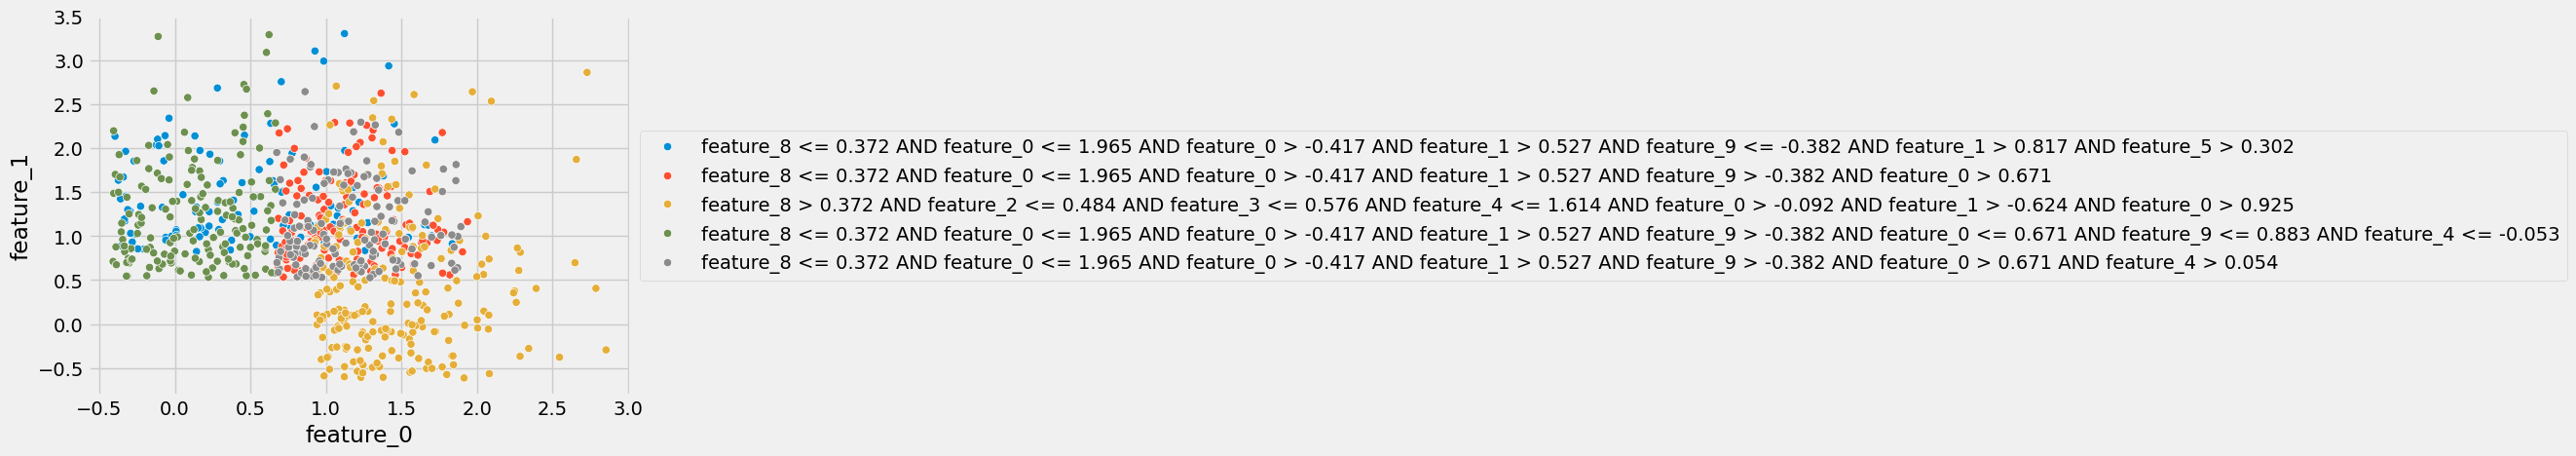

In [15]:
# create a single plot with the 5 classes based on each recommendation
import polars as pl

df_plot = pd.DataFrame(columns=['feature_0', 'feature_1', 'condition'])
for i in [4,2, 3,1,0]:
    condition = top_ct_p.iloc[i]['condition']
    dt = data.execute(condition)
    dt = dt[['feature_0', 'feature_1']]

    dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])
    dt['condition'] = condition

    df_plot = pd.concat([df_plot, dt], ignore_index=True)
    
sns.scatterplot(x='feature_0', y='feature_1', hue='condition', data=df_plot)
# reduce legend size
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

# Visualizations from the CF

In [16]:
top_cf = scores[(scores['algorithm']=='CF')]
top_cf

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,unique_between_K,true_score,algorithm,execution_time
10,feature_0 <= -0.017 AND feature_1 > 0.788 AND ...,140.520,0.001,NaN,NaN,7,20,0.0020,0.002285,1.00,0.50,0.434,6.0,0.989239,0.04,CF,21.33
11,feature_0 <= 0.012 AND feature_1 > -0.848 AND ...,121.523,0.004,NaN,NaN,10,39,0.0039,0.004456,0.86,0.43,0.863,6.0,0.989239,0.08,CF,21.33
12,feature_0 > 0.016 AND feature_1 <= 0.716 AND f...,119.749,0.002,NaN,NaN,15,17,0.0017,0.001942,0.85,0.43,0.900,7.0,0.989239,0.08,CF,21.33
13,feature_1 > -1.373,0.889,0.811,NaN,NaN,1,9191,0.9191,1.050040,0.01,0.41,0.885,1.0,0.989239,0.48,CF,21.33
14,feature_0 > 0.075 AND feature_2 > -0.874 AND f...,110.383,0.002,NaN,NaN,12,26,0.0026,0.002970,0.79,0.39,1.580,5.0,0.989239,0.14,CF,21.33


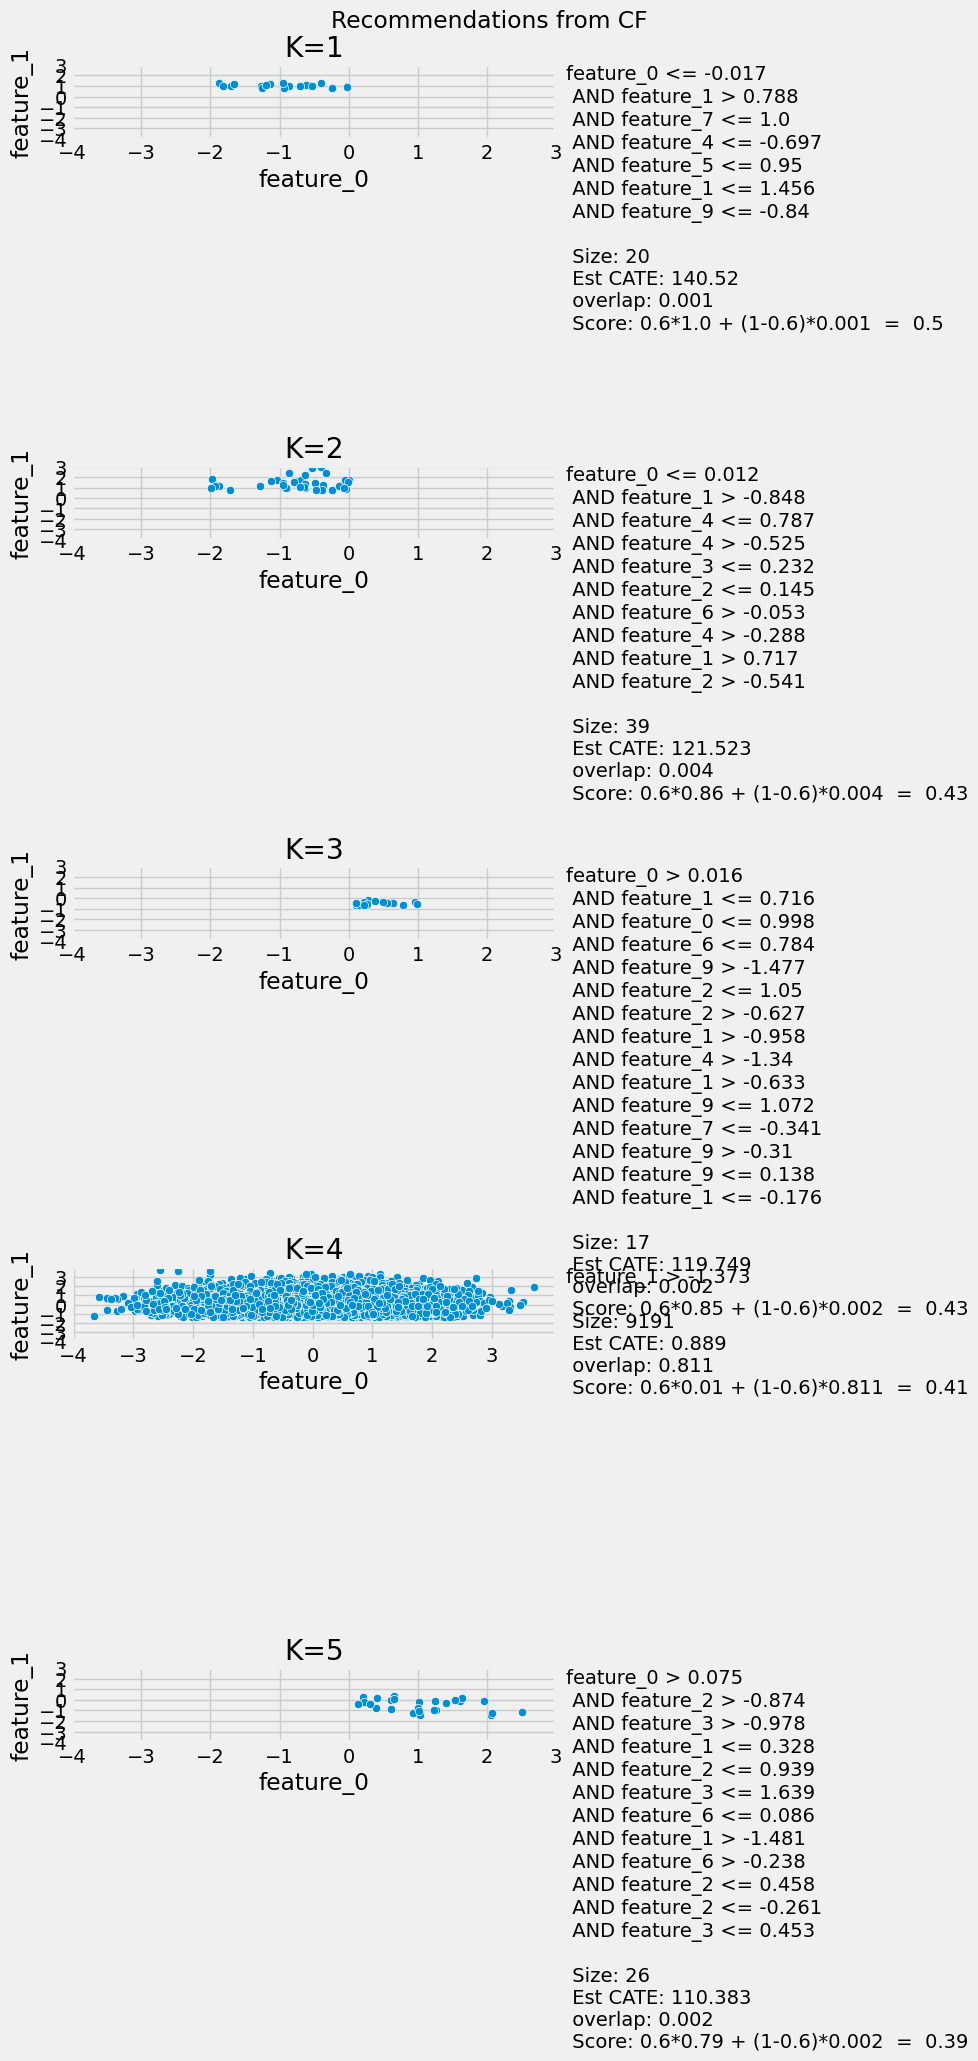

In [17]:
visualize_recommendations2(data,top_cf)

# Visualizations from Brute Force

In [18]:
top_bf = scores[(scores['algorithm']=='Brute Force (Oracle)')]
top_bf

,condition,t_est,overlap,T0,T1,depth,rows,selectivity,selectivity_to_P_ratio,norm_cate,score,t,features,unique_between_K,true_score,algorithm,execution_time
20,feature_0 > 1.84 AND feature_1 > 0.94 AND feat...,3.988,0.006,NaN,NaN,3,60,0.0060,0.006855,1.00,0.50,3.988,2.0,0.966986,0.35,Brute Force (Oracle),1.91
21,feature_0 > -0.66,1.260,0.675,NaN,NaN,1,7469,0.7469,0.853307,0.32,0.50,1.260,1.0,0.966986,0.45,Brute Force (Oracle),1.91
22,feature_0 > 1.34 AND feature_1 > 1.44 AND feat...,3.871,0.007,NaN,NaN,3,74,0.0074,0.008454,0.97,0.49,3.871,2.0,0.966986,0.34,Brute Force (Oracle),1.91
23,feature_0 > 0.84 AND feature_0 < 2.84 AND feat...,3.822,0.005,NaN,NaN,4,55,0.0055,0.006284,0.96,0.48,3.822,2.0,0.966986,0.34,Brute Force (Oracle),1.91
24,feature_0 > 2.34 AND feature_1 > -0.56 AND fea...,3.785,0.007,NaN,NaN,3,66,0.0066,0.007540,0.95,0.48,3.785,2.0,0.966986,0.34,Brute Force (Oracle),1.91


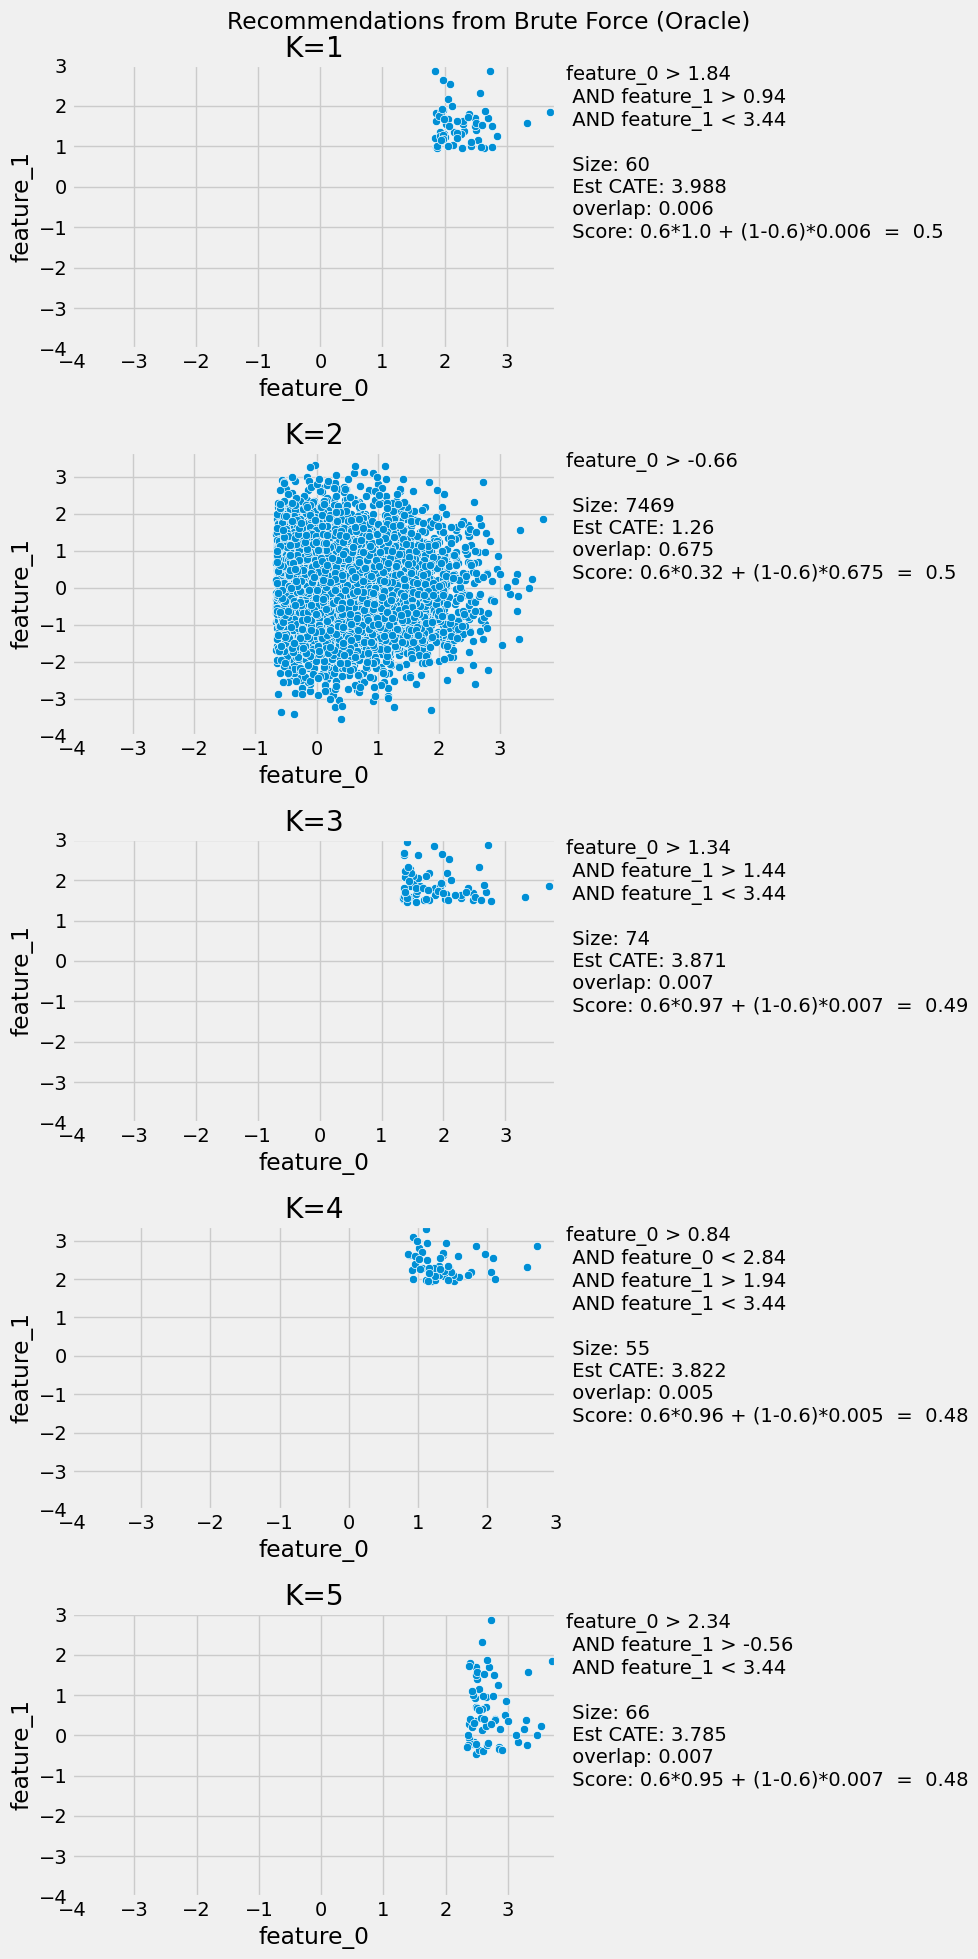

In [19]:
visualize_recommendations2(data,top_bf)